# Trees


In [1]:
from pathlib import Path
import sys
import importlib
import polars as pl 

pl.Config.set_tbl_rows(1000)   # allow many rows
pl.Config.set_tbl_cols(100)    # allow many columns
pl.Config.set_tbl_width_chars(200)


current = Path.cwd()

while current.name != "shared-notebooks":
    if current.parent == current:
        raise RuntimeError("Could not locate shared-notebooks directory")
    current = current.parent

utils_path = current / "common_utils" / "python"
if str(utils_path) not in sys.path:
    sys.path.append(str(utils_path))

import load_flight_data
importlib.reload(load_flight_data)

lf = load_flight_data.load_flight_data(file_name = 'flights_canonical_2019.parquet')

RAW_FEATURES = [
    "flight_id",
    "tail_number",
    "reporting_airline",
    "origin",
    "dest",
    "route_key",
    "distance",
    "flight_date",

    # local calendar/time features
    "dep_hour_local",
    "dep_weekday_local",
    "dep_month_local",

    # UTC timestamps for sequencing
    "dep_ts_sched_utc",
    "dep_ts_actual_utc",
    "arr_ts_sched_utc",
    "arr_ts_actual_utc",

    # weather
    "dep_temp_c",
    "dep_wind_speed_m_s",
    "dep_wind_dir_deg",
    "dep_ceiling_height_m",
    "arr_temp_c",
    "arr_wind_speed_m_s",
    "arr_wind_dir_deg",
    "arr_ceiling_height_m",

    # existing same-tail linkage
    "prev_flight_id_same_tail",
    "next_flight_id_same_tail",
    "prev_origin",
    "prev_dest",
    "next_origin",
    "next_dest",
    "prev_arr_ts_actual_utc",
    "next_dep_ts_actual_utc",

    # delays
    "dep_delay",
    "dep_del15",
    "arr_delay",
    "arr_del15",

    # existing lag features
    "prev_arr_delay",
    "prev_dep_delay",
    "next_arr_delay",
    "next_dep_delay",
    "prev_arr_del15",
    "prev_dep_del15",
    "next_dep_del15",
    "next_arr_del15",
    "prev_arr_late_15",
    "prev_dep_late_15",
    "next_arr_late_15",
    "next_dep_late_15",

    # rotation features
    "turnaround_minutes",
    "next_turnaround_minutes",
    "rotation_continuity_flag",
    "next_rotation_continuity_flag",
    "aircraft_leg_number_day",
    "cum_dep_delay_aircraft_day",
    "cum_arr_delay_aircraft_day",

    # status flags
    "is_cancelled",
    "is_diverted",

    # optional schedule block features
    "crs_elapsed_time",
    "dep_time_blk",
    "arr_time_blk",
]

# ---------------------------
# US Federal Holidays (2019 example)
# ---------------------------
US_HOLIDAYS_2019 = [
    "2019-01-01",  # New Year's Day
    "2019-01-21",  # MLK Day
    "2019-02-18",  # Presidents Day
    "2019-05-27",  # Memorial Day
    "2019-07-04",  # Independence Day
    "2019-09-02",  # Labor Day
    "2019-10-14",  # Columbus Day
    "2019-11-11",  # Veterans Day
    "2019-11-28",  # Thanksgiving
    "2019-12-25",  # Christmas
]

ml_lf = (
    lf
    .select(RAW_FEATURES)
    .filter(
        (pl.col("is_cancelled") == 0) &
        (pl.col("is_diverted") == 0) &
        pl.col("arr_del15").is_not_null() &
        pl.col("tail_number").is_not_null() &
        pl.col("dep_ts_actual_utc").is_not_null() &
        pl.col("arr_ts_actual_utc").is_not_null()
    )
)

lf_features = (
    ml_lf
    .with_columns([

        # ---------------------------
        # TIME OF DAY BUCKETS
        # ---------------------------
        pl.when(pl.col("dep_hour_local") < 6).then(1)   # early morning
        .when(pl.col("dep_hour_local") < 11).then(2)    # morning
        .when(pl.col("dep_hour_local") < 14).then(3)    # midday
        .when(pl.col("dep_hour_local") < 18).then(4)    # afternoon
        .when(pl.col("dep_hour_local") < 21).then(5)    # evening
        .otherwise(6)                                   # night
        .alias("dep_time_bucket"),

        # ---------------------------
        # WEEKEND FLAG
        # ---------------------------
        pl.col("dep_weekday_local").is_in([6, 7]).cast(pl.Int8).alias("is_weekend"),

        # ---------------------------
        # HOLIDAY FLAG
        # ---------------------------
        pl.col("flight_date")
        .cast(pl.Utf8)
        .is_in(US_HOLIDAYS_2019)
        .cast(pl.Int8)
        .alias("is_holiday"),

        # ---------------------------
        # DAYS TO NEAREST HOLIDAY (VERY POWERFUL)
        # ---------------------------
        pl.min_horizontal([
            *[
                (pl.col("flight_date").cast(pl.Date) - pl.lit(h).str.strptime(pl.Date)).abs().dt.total_days()
                for h in US_HOLIDAYS_2019
            ]
        ]).alias("days_to_nearest_holiday"),

        # ---------------------------
        # ROUTE FREQUENCY (proxy for traffic density)
        # ---------------------------
        pl.count().over("route_key").alias("route_frequency"),

        # ---------------------------
        # AIRPORT TRAFFIC (congestion proxy)
        # ---------------------------
        pl.count().over("origin").alias("origin_flight_volume"),
        pl.count().over("dest").alias("dest_flight_volume"),

        # ---------------------------
        # DELAY PROPAGATION STRENGTH
        # ---------------------------
        (pl.col("prev_arr_delay") > 15).cast(pl.Int8).alias("prev_arr_delayed_flag"),

        (
            pl.col("prev_arr_delay") +
            pl.col("prev_dep_delay")
        ).alias("prev_total_delay"),

        # ---------------------------
        # TURNAROUND PRESSURE
        # ---------------------------
        (
            pl.col("turnaround_minutes") < 60
        ).cast(pl.Int8).alias("tight_turnaround_flag"),

        # ---------------------------
        # RELATIVE POSITION IN DAY
        # ---------------------------
        (
            pl.col("aircraft_leg_number_day") /
            pl.max("aircraft_leg_number_day").over("tail_number")
        ).alias("relative_leg_position"),

    ])
)

usa_2hop_lf = (
    lf_features
    .sort(["tail_number", "dep_ts_actual_utc"])
    .with_columns([
        # 1 hop back
        pl.col("flight_id").shift(1).over("tail_number").alias("prev1_flight_id"),
        pl.col("origin").shift(1).over("tail_number").alias("prev1_origin"),
        pl.col("dest").shift(1).over("tail_number").alias("prev1_dest"),
        pl.col("dep_ts_actual_utc").shift(1).over("tail_number").alias("prev1_dep_ts_utc"),
        pl.col("arr_ts_actual_utc").shift(1).over("tail_number").alias("prev1_arr_ts_utc"),
        pl.col("arr_delay").shift(1).over("tail_number").alias("prev1_arr_delay"),
        pl.col("dep_delay").shift(1).over("tail_number").alias("prev1_dep_delay"),
        pl.col("arr_del15").shift(1).over("tail_number").alias("prev1_arr_del15"),
        pl.col("dep_del15").shift(1).over("tail_number").alias("prev1_dep_del15"),

        # 2 hops back
        pl.col("flight_id").shift(2).over("tail_number").alias("prev2_flight_id"),
        pl.col("origin").shift(2).over("tail_number").alias("prev2_origin"),
        pl.col("dest").shift(2).over("tail_number").alias("prev2_dest"),
        pl.col("dep_ts_actual_utc").shift(2).over("tail_number").alias("prev2_dep_ts_utc"),
        pl.col("arr_ts_actual_utc").shift(2).over("tail_number").alias("prev2_arr_ts_utc"),
        pl.col("arr_delay").shift(2).over("tail_number").alias("prev2_arr_delay"),
        pl.col("dep_delay").shift(2).over("tail_number").alias("prev2_dep_delay"),
        pl.col("arr_del15").shift(2).over("tail_number").alias("prev2_arr_del15"),
        pl.col("dep_del15").shift(2).over("tail_number").alias("prev2_dep_del15"),

        # timing gaps
        (
            pl.col("dep_ts_actual_utc") -
            pl.col("arr_ts_actual_utc").shift(1).over("tail_number")
        ).dt.total_minutes().alias("prev1_turnaround_minutes"),

        (
            pl.col("dep_ts_actual_utc") -
            pl.col("arr_ts_actual_utc").shift(2).over("tail_number")
        ).dt.total_minutes().alias("time_since_prev2_arrival_minutes"),
    ])
    .filter(
        pl.col("prev1_flight_id").is_not_null() &
        pl.col("prev2_flight_id").is_not_null() &
        pl.col("prev1_turnaround_minutes").is_not_null() &
        pl.col("time_since_prev2_arrival_minutes").is_not_null() &
        pl.col("prev1_turnaround_minutes").is_between(0, 12 * 60) &
        pl.col("time_since_prev2_arrival_minutes").is_between(0, 24 * 60)
    )
)

flights = usa_2hop_lf.collect()
print(flights.height)
print(flights.head())


/home/jon/Documents/grad_school/OR568/project/OR568_ML_Project/shared-notebooks/common_utils/python/load_flight_data.py:89: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  cleaned = _clean_names(lf.columns)
/home/jon/Documents/grad_school/OR568/project/OR568_ML_Project/shared-notebooks/common_utils/python/load_flight_data.py:90: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  lf = lf.rename(dict(zip(lf.columns, cleaned)))
/tmp/ipykernel_45540/4051844013.py:178: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().over("route_key").alias("route_frequency"),
/tmp/ip

6594553
shape: (5, 90)
┌─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┐
│ fli ┆ tai ┆ rep ┆ ori ┆ des ┆ rou ┆ dis ┆ fli ┆ dep ┆ dep ┆ dep ┆ dep ┆ dep ┆ arr ┆ arr ┆ dep ┆ dep ┆ dep ┆ dep ┆ arr ┆ arr ┆ arr ┆ arr ┆ pre ┆ nex ┆ pre ┆ pre ┆ nex ┆ nex ┆ pre ┆ nex ┆ dep ┆ dep ┆ arr ┆ arr ┆ pre ┆ pre ┆ nex ┆ nex ┆ pre ┆ pre ┆ nex ┆ nex ┆ pre ┆ pre ┆ nex ┆ nex ┆ tur ┆ nex ┆ rot ┆ nex ┆ air ┆ cum ┆ cum ┆ is_ ┆ is_ ┆ crs ┆ dep ┆ arr ┆ dep ┆ is_ ┆ is_ ┆ day ┆ rou ┆ ori ┆ des ┆ pre ┆ pre ┆ tig ┆ rel ┆ pre ┆ pre ┆ p

## Rotations and prop

Shape: (3441, 104)
  origin dest  arr_del15
0    JFK  BWI        1.0
1    BWI  JFK        0.0
2    EWR  BWI        0.0
3    EWR  BWI        1.0
4    EWR  BWI        1.0
Model frame shape: (3441, 66)
arr_del15
0    2799
1     642
Name: count, dtype: int64
Categorical columns: 10
Numeric columns: 55

================ MODEL COMPARISON ================

           model  accuracy  precision    recall        f1   roc_auc    pr_auc
0        xgboost  0.947750   0.890756  0.821705  0.854839  0.974779  0.922183
1  random_forest  0.901306   0.710345  0.798450  0.751825  0.944712  0.830824
2     tree_tuned  0.867925   0.598958  0.891473  0.716511  0.923235  0.749433
3      tree_base  0.856313   0.574257  0.899225  0.700906  0.905689  0.705876


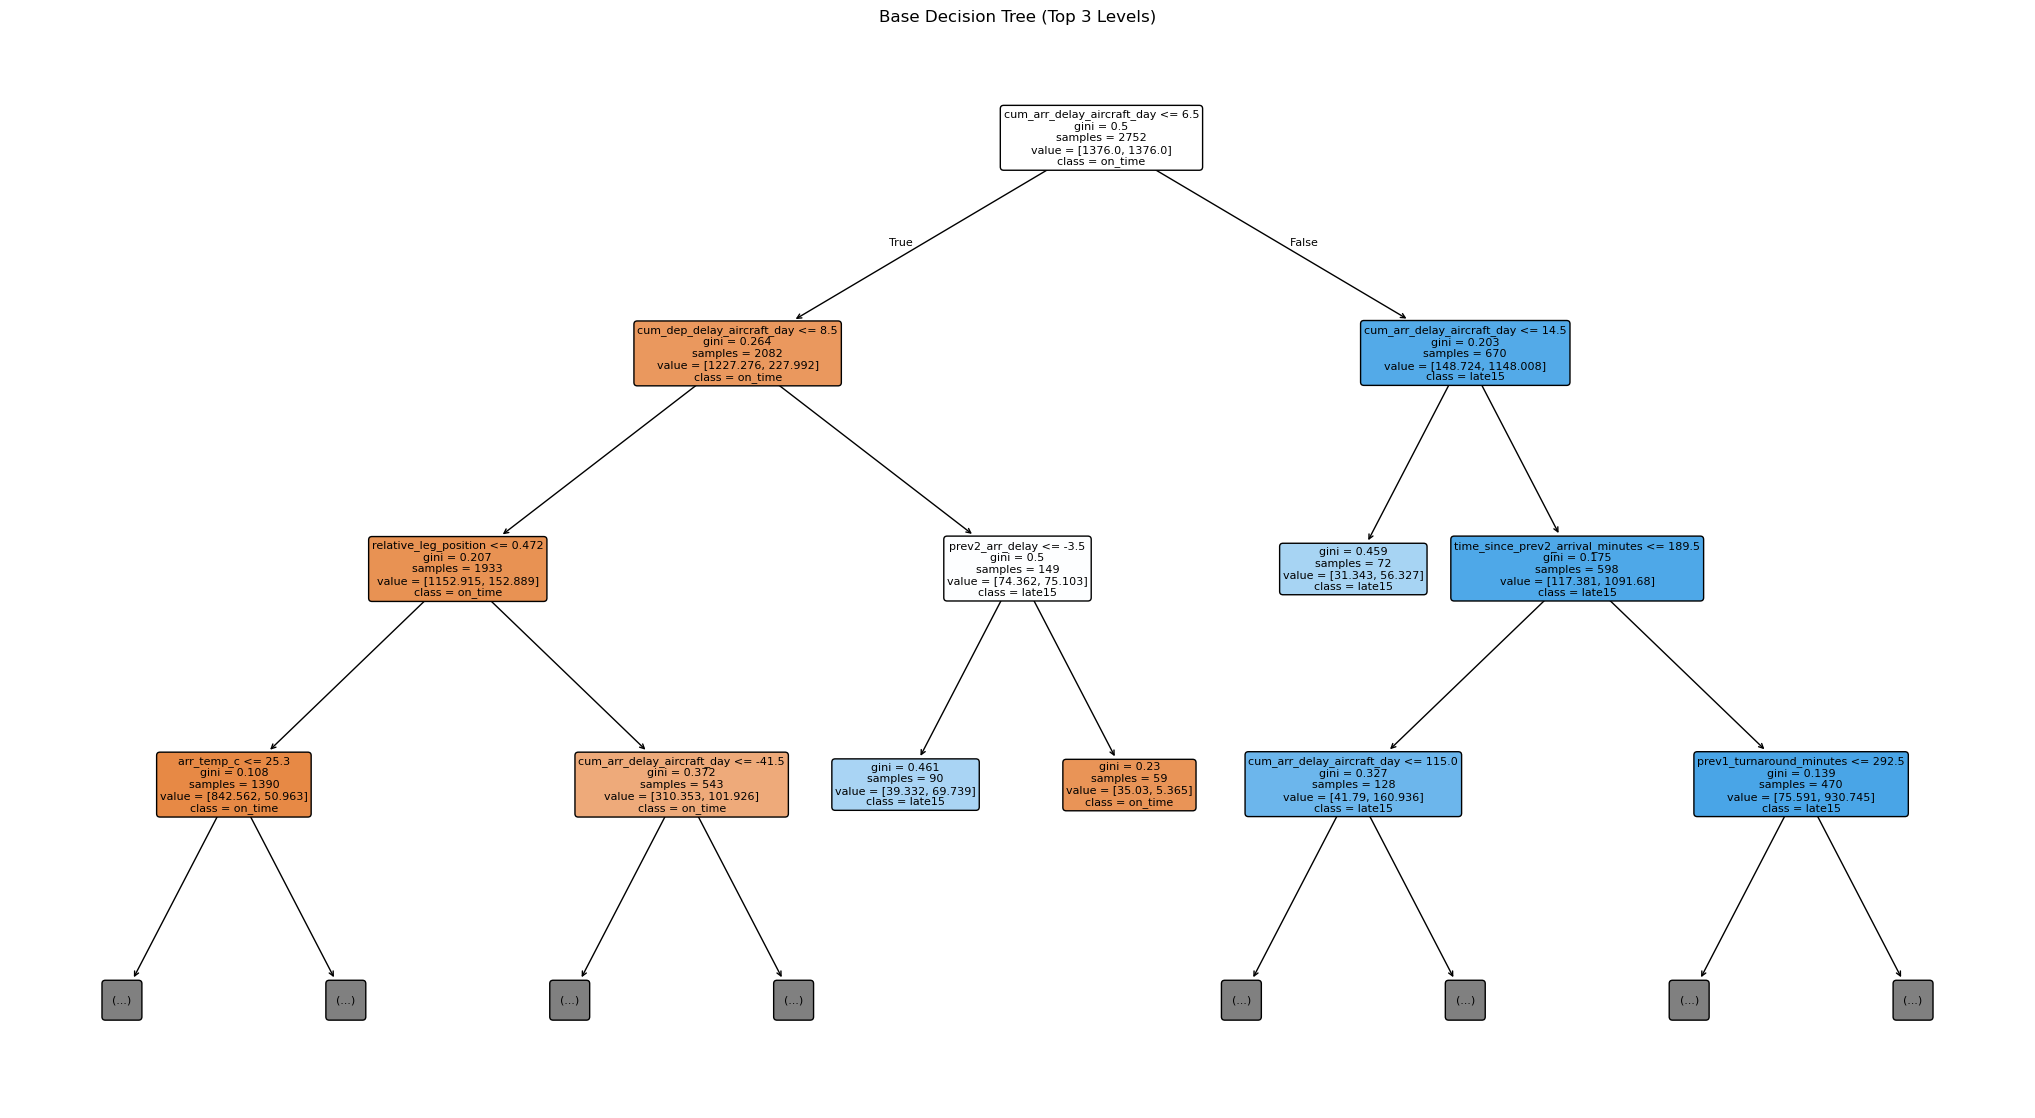

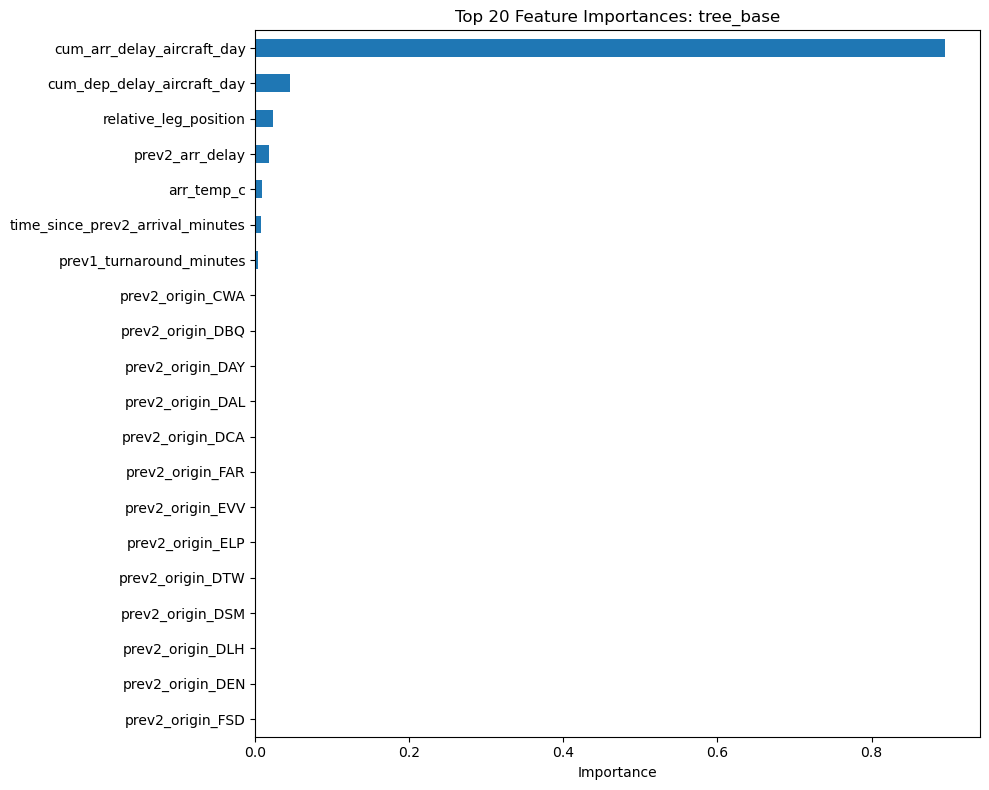


Top built-in feature importances for tree_base:
cum_arr_delay_aircraft_day          0.896087
cum_dep_delay_aircraft_day          0.045410
relative_leg_position               0.023262
prev2_arr_delay                     0.017245
arr_temp_c                          0.008212
time_since_prev2_arrival_minutes    0.006604
prev1_turnaround_minutes            0.003181
prev2_origin_FSD                    0.000000
prev2_origin_FAR                    0.000000
prev2_origin_EVV                    0.000000
prev2_origin_ELP                    0.000000
prev2_origin_DTW                    0.000000
prev2_origin_DSM                    0.000000
prev2_origin_DLH                    0.000000
prev2_origin_DEN                    0.000000
prev2_origin_DCA                    0.000000
prev2_origin_DBQ                    0.000000
prev2_origin_DAY                    0.000000
prev2_origin_DAL                    0.000000
prev2_origin_CWA                    0.000000
dtype: float64


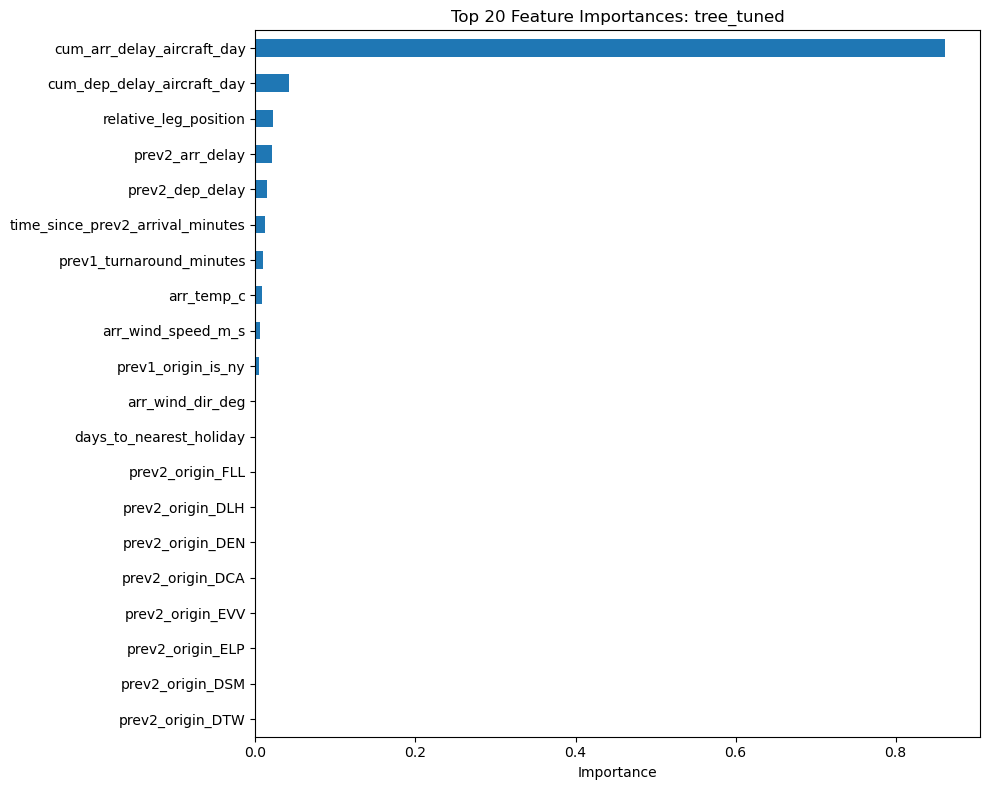


Top built-in feature importances for tree_tuned:
cum_arr_delay_aircraft_day          0.862390
cum_dep_delay_aircraft_day          0.042137
relative_leg_position               0.021586
prev2_arr_delay                     0.020501
prev2_dep_delay                     0.014015
time_since_prev2_arrival_minutes    0.011635
prev1_turnaround_minutes            0.009220
arr_temp_c                          0.007620
arr_wind_speed_m_s                  0.006203
prev1_origin_is_ny                  0.003876
arr_wind_dir_deg                    0.000776
days_to_nearest_holiday             0.000041
prev2_origin_DTW                    0.000000
prev2_origin_DSM                    0.000000
prev2_origin_ELP                    0.000000
prev2_origin_EVV                    0.000000
prev2_origin_FLL                    0.000000
prev2_origin_DLH                    0.000000
prev2_origin_DEN                    0.000000
prev2_origin_DCA                    0.000000
dtype: float64


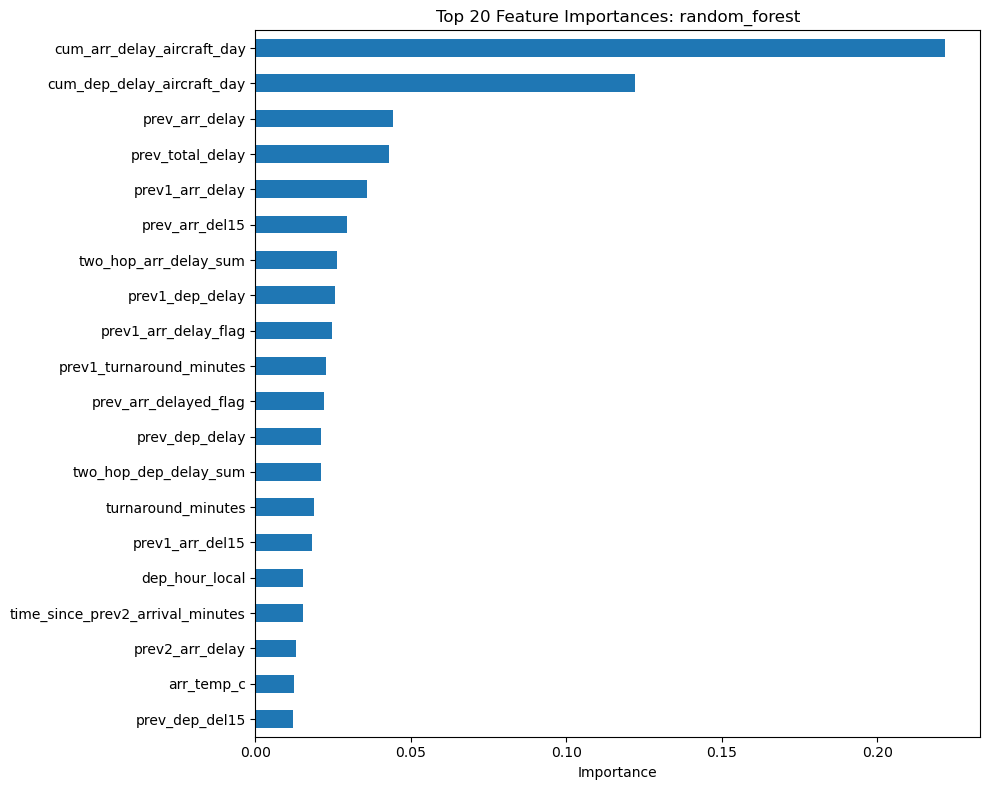


Top built-in feature importances for random_forest:
cum_arr_delay_aircraft_day          0.221923
cum_dep_delay_aircraft_day          0.122146
prev_arr_delay                      0.044073
prev_total_delay                    0.043047
prev1_arr_delay                     0.035892
prev_arr_del15                      0.029458
two_hop_arr_delay_sum               0.026099
prev1_dep_delay                     0.025675
prev1_arr_delay_flag                0.024708
prev1_turnaround_minutes            0.022584
prev_arr_delayed_flag               0.022164
prev_dep_delay                      0.021218
two_hop_dep_delay_sum               0.020958
turnaround_minutes                  0.018884
prev1_arr_del15                     0.018046
dep_hour_local                      0.015435
time_since_prev2_arrival_minutes    0.015226
prev2_arr_delay                     0.013055
arr_temp_c                          0.012352
prev_dep_del15                      0.012063
dtype: float64


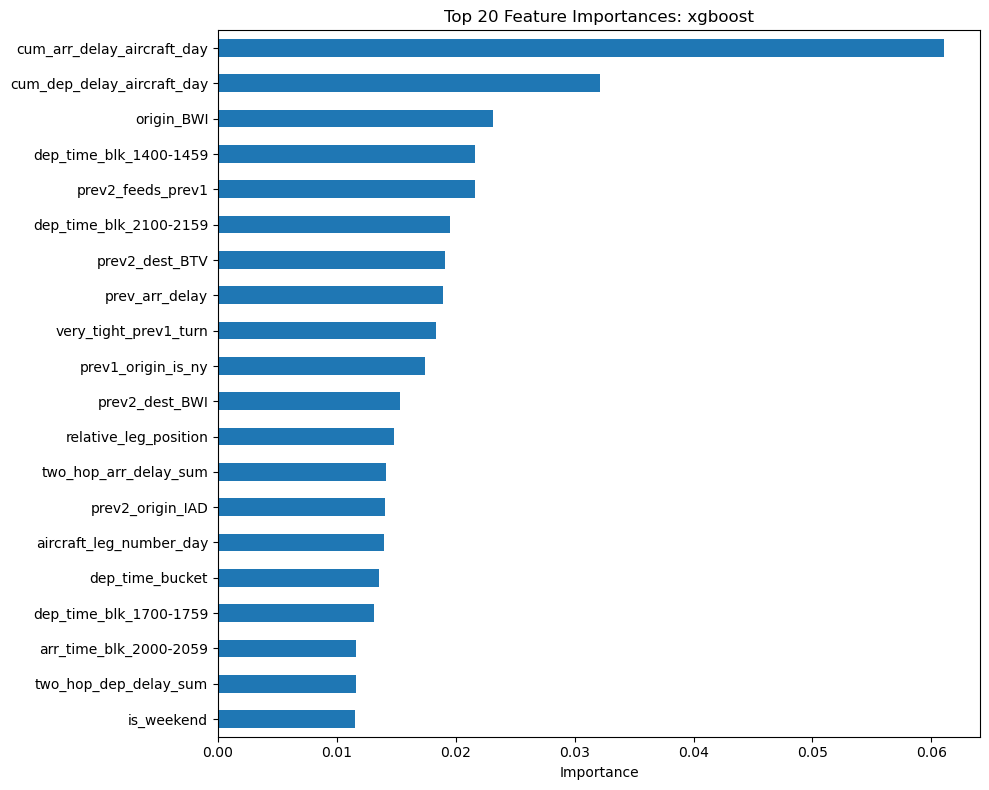


Top built-in feature importances for xgboost:
cum_arr_delay_aircraft_day    0.061035
cum_dep_delay_aircraft_day    0.032155
origin_BWI                    0.023149
dep_time_blk_1400-1459        0.021633
prev2_feeds_prev1             0.021601
dep_time_blk_2100-2159        0.019514
prev2_dest_BTV                0.019116
prev_arr_delay                0.018897
very_tight_prev1_turn         0.018371
prev1_origin_is_ny            0.017388
prev2_dest_BWI                0.015319
relative_leg_position         0.014837
two_hop_arr_delay_sum         0.014168
prev2_origin_IAD              0.014087
aircraft_leg_number_day       0.013924
dep_time_bucket               0.013563
dep_time_blk_1700-1759        0.013134
arr_time_blk_2000-2059        0.011626
two_hop_dep_delay_sum         0.011570
is_weekend                    0.011512
dtype: float32


<Figure size 1000x800 with 0 Axes>

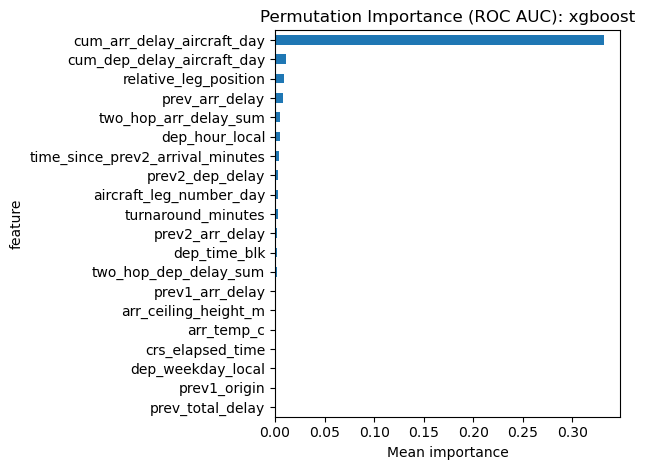


Top permutation importance features for xgboost:
                             feature  importance_mean  importance_std
38        cum_arr_delay_aircraft_day         0.331534        0.014399
37        cum_dep_delay_aircraft_day         0.010623        0.001173
36             relative_leg_position         0.009233        0.002714
26                    prev_arr_delay         0.008045        0.001231
59             two_hop_arr_delay_sum         0.004839        0.001273
5                     dep_hour_local         0.004671        0.000910
52  time_since_prev2_arrival_minutes         0.004355        0.001585
48                   prev2_dep_delay         0.002913        0.001311
35           aircraft_leg_number_day         0.002746        0.000586
32                turnaround_minutes         0.002506        0.000609
47                   prev2_arr_delay         0.002420        0.001944
13                      dep_time_blk         0.002107        0.000303
60             two_hop_dep_delay_sum    

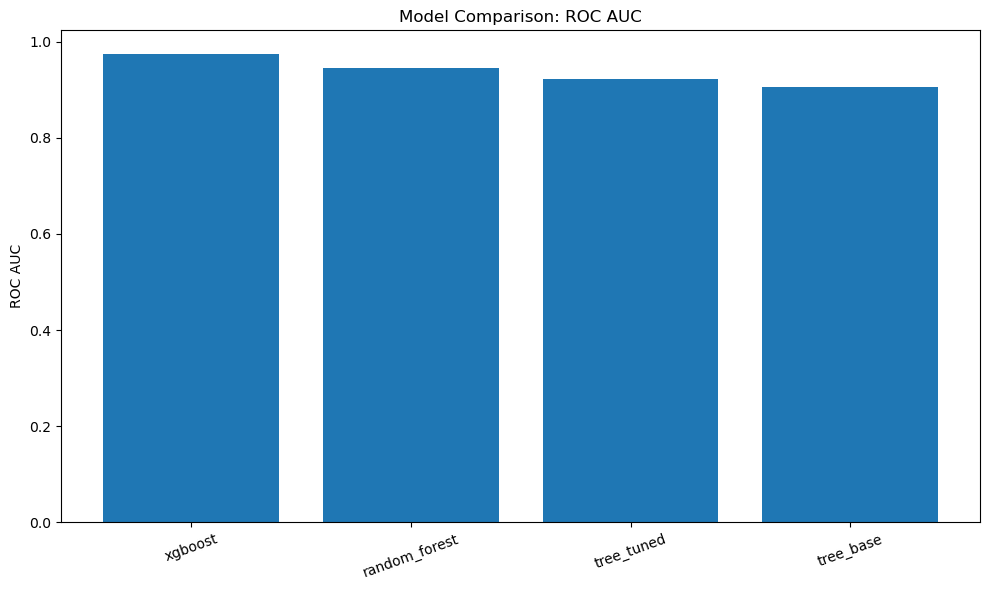

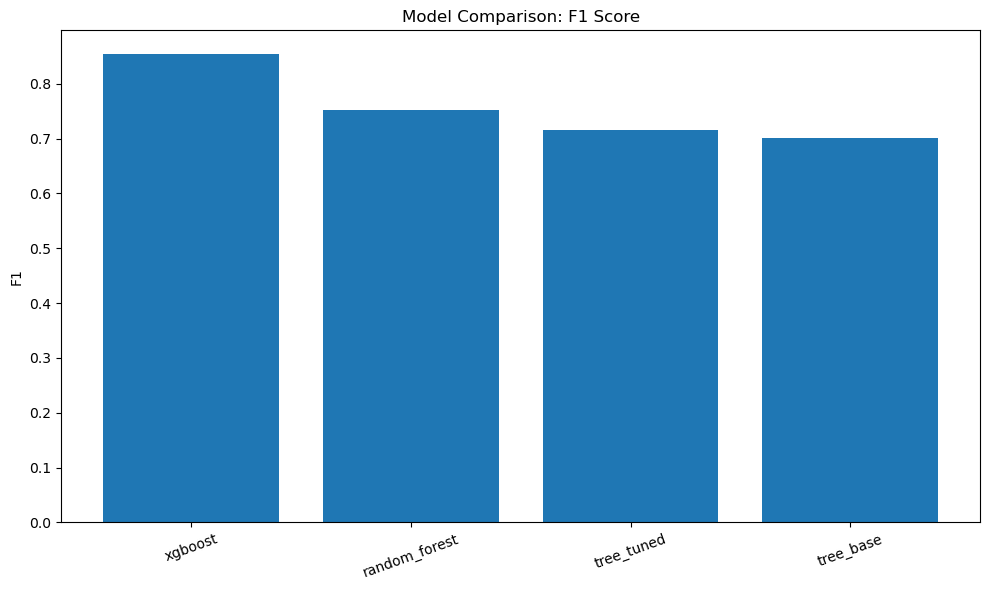

In [6]:
# ============================================================
# TREE-BASED MODELS FOR BWI <-> NEW YORK FLIGHT DELAY MARKET
# ============================================================

from pathlib import Path
import sys
import importlib
import warnings

import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
)
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")

# Optional XGBoost
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False

# ------------------------------------------------------------
# Display config
# ------------------------------------------------------------
pl.Config.set_tbl_rows(1000)
pl.Config.set_tbl_cols(100)
pl.Config.set_tbl_width_chars(200)

# ------------------------------------------------------------
# Locate shared-notebooks and load your common utility
# ------------------------------------------------------------
current = Path.cwd()

while current.name != "shared-notebooks":
    if current.parent == current:
        raise RuntimeError("Could not locate shared-notebooks directory")
    current = current.parent

utils_path = current / "common_utils" / "python"
if str(utils_path) not in sys.path:
    sys.path.append(str(utils_path))

import load_flight_data
importlib.reload(load_flight_data)

# ------------------------------------------------------------
# Load canonical dataset
# ------------------------------------------------------------
lf = load_flight_data.load_flight_data(file_name="flights_canonical_2019.parquet")

# ------------------------------------------------------------
# Base raw features from your pipeline
# ------------------------------------------------------------
RAW_FEATURES = [
    "flight_id",
    "tail_number",
    "reporting_airline",
    "origin",
    "dest",
    "route_key",
    "distance",
    "flight_date",

    # local calendar/time features
    "dep_hour_local",
    "dep_weekday_local",
    "dep_month_local",

    # UTC timestamps for sequencing
    "dep_ts_sched_utc",
    "dep_ts_actual_utc",
    "arr_ts_sched_utc",
    "arr_ts_actual_utc",

    # weather
    "dep_temp_c",
    "dep_wind_speed_m_s",
    "dep_wind_dir_deg",
    "dep_ceiling_height_m",
    "arr_temp_c",
    "arr_wind_speed_m_s",
    "arr_wind_dir_deg",
    "arr_ceiling_height_m",

    # existing same-tail linkage
    "prev_flight_id_same_tail",
    "next_flight_id_same_tail",
    "prev_origin",
    "prev_dest",
    "next_origin",
    "next_dest",
    "prev_arr_ts_actual_utc",
    "next_dep_ts_actual_utc",

    # delays
    "dep_delay",
    "dep_del15",
    "arr_delay",
    "arr_del15",

    # existing lag features
    "prev_arr_delay",
    "prev_dep_delay",
    "next_arr_delay",
    "next_dep_delay",
    "prev_arr_del15",
    "prev_dep_del15",
    "next_dep_del15",
    "next_arr_del15",
    "prev_arr_late_15",
    "prev_dep_late_15",
    "next_arr_late_15",
    "next_dep_late_15",

    # rotation features
    "turnaround_minutes",
    "next_turnaround_minutes",
    "rotation_continuity_flag",
    "next_rotation_continuity_flag",
    "aircraft_leg_number_day",
    "cum_dep_delay_aircraft_day",
    "cum_arr_delay_aircraft_day",

    # status flags
    "is_cancelled",
    "is_diverted",

    # optional schedule block features
    "crs_elapsed_time",
    "dep_time_blk",
    "arr_time_blk",
]

# ------------------------------------------------------------
# Holiday list
# ------------------------------------------------------------
US_HOLIDAYS_2019 = [
    "2019-01-01",
    "2019-01-21",
    "2019-02-18",
    "2019-05-27",
    "2019-07-04",
    "2019-09-02",
    "2019-10-14",
    "2019-11-11",
    "2019-11-28",
    "2019-12-25",
]

NY_AIRPORTS = ["JFK", "LGA", "EWR"]

# ------------------------------------------------------------
# Initial filter
# ------------------------------------------------------------
ml_lf = (
    lf
    .select(RAW_FEATURES)
    .filter(
        (pl.col("is_cancelled") == 0) &
        (pl.col("is_diverted") == 0) &
        pl.col("arr_del15").is_not_null() &
        pl.col("tail_number").is_not_null() &
        pl.col("dep_ts_actual_utc").is_not_null() &
        pl.col("arr_ts_actual_utc").is_not_null()
    )
)

# ------------------------------------------------------------
# Feature engineering
# ------------------------------------------------------------
lf_features = (
    ml_lf
    .with_columns([
        # time buckets
        pl.when(pl.col("dep_hour_local") < 6).then(1)
        .when(pl.col("dep_hour_local") < 11).then(2)
        .when(pl.col("dep_hour_local") < 14).then(3)
        .when(pl.col("dep_hour_local") < 18).then(4)
        .when(pl.col("dep_hour_local") < 21).then(5)
        .otherwise(6)
        .alias("dep_time_bucket"),

        # weekend
        pl.col("dep_weekday_local").is_in([6, 7]).cast(pl.Int8).alias("is_weekend"),

        # holiday
        pl.col("flight_date")
        .cast(pl.Utf8)
        .is_in(US_HOLIDAYS_2019)
        .cast(pl.Int8)
        .alias("is_holiday"),

        # days to nearest holiday
        pl.min_horizontal([
            *[
                (pl.col("flight_date").cast(pl.Date) - pl.lit(h).str.strptime(pl.Date)).abs().dt.total_days()
                for h in US_HOLIDAYS_2019
            ]
        ]).alias("days_to_nearest_holiday"),

        # route and airport traffic proxies
        pl.len().over("route_key").alias("route_frequency"),
        pl.len().over("origin").alias("origin_flight_volume"),
        pl.len().over("dest").alias("dest_flight_volume"),

        # propagation / rotation
        (pl.col("prev_arr_delay") > 15).cast(pl.Int8).alias("prev_arr_delayed_flag"),
        (pl.col("prev_arr_delay") + pl.col("prev_dep_delay")).alias("prev_total_delay"),
        (pl.col("turnaround_minutes") < 60).cast(pl.Int8).alias("tight_turnaround_flag"),

        (
            pl.col("aircraft_leg_number_day") /
            pl.max("aircraft_leg_number_day").over("tail_number")
        ).alias("relative_leg_position"),
    ])
)

# ------------------------------------------------------------
# Build 2-hop same-tail network context
# ------------------------------------------------------------
usa_2hop_lf = (
    lf_features
    .sort(["tail_number", "dep_ts_actual_utc"])
    .with_columns([
        # 1 hop back
        pl.col("flight_id").shift(1).over("tail_number").alias("prev1_flight_id"),
        pl.col("origin").shift(1).over("tail_number").alias("prev1_origin"),
        pl.col("dest").shift(1).over("tail_number").alias("prev1_dest"),
        pl.col("dep_ts_actual_utc").shift(1).over("tail_number").alias("prev1_dep_ts_utc"),
        pl.col("arr_ts_actual_utc").shift(1).over("tail_number").alias("prev1_arr_ts_utc"),
        pl.col("arr_delay").shift(1).over("tail_number").alias("prev1_arr_delay"),
        pl.col("dep_delay").shift(1).over("tail_number").alias("prev1_dep_delay"),
        pl.col("arr_del15").shift(1).over("tail_number").alias("prev1_arr_del15"),
        pl.col("dep_del15").shift(1).over("tail_number").alias("prev1_dep_del15"),

        # 2 hops back
        pl.col("flight_id").shift(2).over("tail_number").alias("prev2_flight_id"),
        pl.col("origin").shift(2).over("tail_number").alias("prev2_origin"),
        pl.col("dest").shift(2).over("tail_number").alias("prev2_dest"),
        pl.col("dep_ts_actual_utc").shift(2).over("tail_number").alias("prev2_dep_ts_utc"),
        pl.col("arr_ts_actual_utc").shift(2).over("tail_number").alias("prev2_arr_ts_utc"),
        pl.col("arr_delay").shift(2).over("tail_number").alias("prev2_arr_delay"),
        pl.col("dep_delay").shift(2).over("tail_number").alias("prev2_dep_delay"),
        pl.col("arr_del15").shift(2).over("tail_number").alias("prev2_arr_del15"),
        pl.col("dep_del15").shift(2).over("tail_number").alias("prev2_dep_del15"),

        # timing gaps
        (
            pl.col("dep_ts_actual_utc") -
            pl.col("arr_ts_actual_utc").shift(1).over("tail_number")
        ).dt.total_minutes().alias("prev1_turnaround_minutes"),

        (
            pl.col("dep_ts_actual_utc") -
            pl.col("arr_ts_actual_utc").shift(2).over("tail_number")
        ).dt.total_minutes().alias("time_since_prev2_arrival_minutes"),
    ])
    .with_columns([
        # NY markers
        pl.col("origin").is_in(NY_AIRPORTS).cast(pl.Int8).alias("origin_is_ny"),
        pl.col("dest").is_in(NY_AIRPORTS).cast(pl.Int8).alias("dest_is_ny"),
        pl.col("prev1_origin").is_in(NY_AIRPORTS).cast(pl.Int8).alias("prev1_origin_is_ny"),
        pl.col("prev1_dest").is_in(NY_AIRPORTS).cast(pl.Int8).alias("prev1_dest_is_ny"),
        pl.col("prev2_origin").is_in(NY_AIRPORTS).cast(pl.Int8).alias("prev2_origin_is_ny"),
        pl.col("prev2_dest").is_in(NY_AIRPORTS).cast(pl.Int8).alias("prev2_dest_is_ny"),

        # feed relationships
        (pl.col("prev1_dest") == pl.col("origin")).cast(pl.Int8).alias("prev1_feeds_current_origin"),
        (pl.col("prev2_dest") == pl.col("prev1_origin")).cast(pl.Int8).alias("prev2_feeds_prev1"),

        # lag delay flags
        (pl.col("prev1_arr_delay") > 15).cast(pl.Int8).alias("prev1_arr_delay_flag"),
        (pl.col("prev2_arr_delay") > 15).cast(pl.Int8).alias("prev2_arr_delay_flag"),

        # compressed chain flags
        (pl.col("prev1_turnaround_minutes") < 45).cast(pl.Int8).alias("very_tight_prev1_turn"),
        (pl.col("time_since_prev2_arrival_minutes") < 180).cast(pl.Int8).alias("compressed_two_hop_chain"),

        # two-hop aggregates
        (
            pl.coalesce([pl.col("prev1_arr_delay"), pl.lit(0)]) +
            pl.coalesce([pl.col("prev2_arr_delay"), pl.lit(0)])
        ).alias("two_hop_arr_delay_sum"),

        (
            pl.coalesce([pl.col("prev1_dep_delay"), pl.lit(0)]) +
            pl.coalesce([pl.col("prev2_dep_delay"), pl.lit(0)])
        ).alias("two_hop_dep_delay_sum"),
    ])
)

# ------------------------------------------------------------
# Focus on BWI <-> New York market
# ------------------------------------------------------------
market_lf = (
    usa_2hop_lf
    .filter(
        (
            (pl.col("origin") == "BWI") & pl.col("dest").is_in(NY_AIRPORTS)
        ) |
        (
            (pl.col("dest") == "BWI") & pl.col("origin").is_in(NY_AIRPORTS)
        )
    )
)

# ------------------------------------------------------------
# Collect to pandas
# ------------------------------------------------------------
df = market_lf.collect().to_pandas()

print("Shape:", df.shape)
print(df[["origin", "dest", "arr_del15"]].head())

# ------------------------------------------------------------
# Target
# ------------------------------------------------------------
TARGET = "arr_del15"

# ------------------------------------------------------------
# Predictor selection
# NOTE:
# Excluding arr_delay from predictors.
# Excluding dep_delay / dep_del15 for a cleaner prediction setup.
# Keeping prior-flight delay features because they are operationally meaningful.
# ------------------------------------------------------------
candidate_features = [
    # schedule / market context
    "reporting_airline",
    "origin",
    "dest",
    "route_key",
    "distance",
    "dep_hour_local",
    "dep_weekday_local",
    "dep_month_local",
    "dep_time_bucket",
    "is_weekend",
    "is_holiday",
    "days_to_nearest_holiday",
    "crs_elapsed_time",
    "dep_time_blk",
    "arr_time_blk",

    # weather
    "dep_temp_c",
    "dep_wind_speed_m_s",
    "dep_wind_dir_deg",
    "dep_ceiling_height_m",
    "arr_temp_c",
    "arr_wind_speed_m_s",
    "arr_wind_dir_deg",
    "arr_ceiling_height_m",

    # congestion / market structure
    "route_frequency",
    "origin_flight_volume",
    "dest_flight_volume",

    # existing propagation / rotation
    "prev_arr_delay",
    "prev_dep_delay",
    "prev_arr_del15",
    "prev_dep_del15",
    "prev_arr_delayed_flag",
    "prev_total_delay",
    "turnaround_minutes",
    "tight_turnaround_flag",
    "rotation_continuity_flag",
    "aircraft_leg_number_day",
    "relative_leg_position",
    "cum_dep_delay_aircraft_day",
    "cum_arr_delay_aircraft_day",

    # 2-hop context
    "prev1_origin",
    "prev1_dest",
    "prev2_origin",
    "prev2_dest",
    "prev1_arr_delay",
    "prev1_dep_delay",
    "prev1_arr_del15",
    "prev1_dep_del15",
    "prev2_arr_delay",
    "prev2_dep_delay",
    "prev2_arr_del15",
    "prev2_dep_del15",
    "prev1_turnaround_minutes",
    "time_since_prev2_arrival_minutes",
    "prev1_feeds_current_origin",
    "prev2_feeds_prev1",
    "prev1_arr_delay_flag",
    "prev2_arr_delay_flag",
    "very_tight_prev1_turn",
    "compressed_two_hop_chain",
    "two_hop_arr_delay_sum",
    "two_hop_dep_delay_sum",
    "prev1_origin_is_ny",
    "prev1_dest_is_ny",
    "prev2_origin_is_ny",
    "prev2_dest_is_ny",
]

candidate_features = [c for c in candidate_features if c in df.columns]

model_df = df[candidate_features + [TARGET]].copy()
model_df = model_df[model_df[TARGET].notna()].copy()
model_df[TARGET] = model_df[TARGET].astype(int)

print("Model frame shape:", model_df.shape)
print(model_df[TARGET].value_counts(dropna=False))

# ------------------------------------------------------------
# Train / test split
# ------------------------------------------------------------
X = model_df[candidate_features]
y = model_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ------------------------------------------------------------
# Column typing
# ------------------------------------------------------------
categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = [c for c in X_train.columns if c not in categorical_cols]

print("Categorical columns:", len(categorical_cols))
print("Numeric columns:", len(numeric_cols))

# ------------------------------------------------------------
# Preprocessing
# ------------------------------------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
            ]),
            numeric_cols,
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore")),
            ]),
            categorical_cols,
        ),
    ]
)

# ------------------------------------------------------------
# Models
# 1) Small interpretable tree
# 2) Larger tuned tree
# 3) Random forest
# 4) Gradient boosting or XGBoost
# ------------------------------------------------------------
models = {
    "tree_base": DecisionTreeClassifier(
        max_depth=4,
        min_samples_leaf=50,
        class_weight="balanced",
        random_state=42,
    ),
    "tree_tuned": DecisionTreeClassifier(
        max_depth=6,
        min_samples_leaf=20,
        min_samples_split=80,
        class_weight="balanced",
        random_state=42,
    ),
    "random_forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=8,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=42,
    ),
}

if HAS_XGB:
    models["xgboost"] = XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
    )
else:
    models["gradient_boosting"] = GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42,
    )

# ------------------------------------------------------------
# Fit models and evaluate
# ------------------------------------------------------------
fitted_models = {}
results = []

for model_name, estimator in models.items():
    pipe = Pipeline([
        ("prep", preprocessor),
        ("model", estimator),
    ])

    pipe.fit(X_train, y_train)
    fitted_models[model_name] = pipe

    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    row = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_prob),
        "pr_auc": average_precision_score(y_test, y_prob),
    }
    results.append(row)

results_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False).reset_index(drop=True)

print("\n================ MODEL COMPARISON ================\n")
print(results_df)

# ------------------------------------------------------------
# Helper: get transformed feature names
# ------------------------------------------------------------
def get_feature_names_from_preprocessor(preprocessor, numeric_cols, categorical_cols):
    feature_names = []
    feature_names.extend(numeric_cols)

    if len(categorical_cols) > 0:
        ohe = preprocessor.named_transformers_["cat"].named_steps["onehot"]
        cat_names = ohe.get_feature_names_out(categorical_cols).tolist()
        feature_names.extend(cat_names)

    return feature_names

# ------------------------------------------------------------
# Tree visualization
# ------------------------------------------------------------
tree_pipe = fitted_models["tree_base"]
tree_prep = tree_pipe.named_steps["prep"]
tree_model = tree_pipe.named_steps["model"]

tree_feature_names = get_feature_names_from_preprocessor(
    tree_prep, numeric_cols, categorical_cols
)

plt.figure(figsize=(26, 14))
plot_tree(
    tree_model,
    feature_names=tree_feature_names,
    class_names=["on_time", "late15"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8,
)
plt.title("Base Decision Tree (Top 3 Levels)")
plt.show()

# ------------------------------------------------------------
# Feature importance plots
# ------------------------------------------------------------
def plot_builtin_feature_importance(model_name, fitted_pipe, top_n=20):
    model = fitted_pipe.named_steps["model"]
    prep = fitted_pipe.named_steps["prep"]

    feature_names = get_feature_names_from_preprocessor(prep, numeric_cols, categorical_cols)

    if not hasattr(model, "feature_importances_"):
        print(f"{model_name}: no built-in feature importance available.")
        return None

    imp = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=False)

    top_imp = imp.head(top_n).sort_values(ascending=True)

    plt.figure(figsize=(10, 8))
    top_imp.plot(kind="barh")
    plt.title(f"Top {top_n} Feature Importances: {model_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

    print(f"\nTop built-in feature importances for {model_name}:")
    print(imp.head(top_n))
    return imp

all_importances = {}
for model_name, fitted_pipe in fitted_models.items():
    imp = plot_builtin_feature_importance(model_name, fitted_pipe, top_n=20)
    all_importances[model_name] = imp

# ------------------------------------------------------------
# Permutation importance for best model
# ------------------------------------------------------------
best_model_name = results_df.iloc[0]["model"]
best_pipe = fitted_models[best_model_name]

perm = permutation_importance(
    best_pipe,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=5,
    random_state=42,
)

perm_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False)

plt.figure(figsize=(10, 8))
perm_df.head(20).sort_values("importance_mean").plot(
    x="feature", y="importance_mean", kind="barh", legend=False
)
plt.title(f"Permutation Importance (ROC AUC): {best_model_name}")
plt.xlabel("Mean importance")
plt.tight_layout()
plt.show()

print(f"\nTop permutation importance features for {best_model_name}:")
print(perm_df.head(20))

# ------------------------------------------------------------
# Confusion matrix / detailed report for best model
# ------------------------------------------------------------
best_probs = best_pipe.predict_proba(X_test)[:, 1]
best_pred = (best_probs >= 0.5).astype(int)

print("\n================ BEST MODEL REPORT ================\n")
print("Best model:", best_model_name)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, best_pred))

print("\nClassification Report:")
print(classification_report(y_test, best_pred, digits=3))

# ------------------------------------------------------------
# Market-level network pattern exploration
# ------------------------------------------------------------
analysis_df = X_test.copy()
analysis_df["actual_late15"] = y_test.values
analysis_df["pred_prob_late15"] = best_probs
analysis_df["pred_late15"] = best_pred

summary_cols = [
    c for c in [
        "route_key",
        "origin",
        "dest",
        "prev1_arr_delay_flag",
        "prev2_arr_delay_flag",
        "very_tight_prev1_turn",
        "compressed_two_hop_chain",
        "prev1_feeds_current_origin",
        "prev2_feeds_prev1",
    ] if c in analysis_df.columns
]

network_summary = (
    analysis_df
    .groupby(summary_cols, dropna=False)
    .agg(
        flights=("actual_late15", "size"),
        actual_delay_rate=("actual_late15", "mean"),
        avg_predicted_risk=("pred_prob_late15", "mean"),
    )
    .reset_index()
    .sort_values(["actual_delay_rate", "flights"], ascending=[False, False])
)

print("\n================ NETWORK PATTERN SUMMARY ================\n")
print(network_summary.head(30))

# ------------------------------------------------------------
# Route-level comparison
# ------------------------------------------------------------
route_summary = (
    analysis_df
    .groupby(["origin", "dest"], dropna=False)
    .agg(
        flights=("actual_late15", "size"),
        actual_delay_rate=("actual_late15", "mean"),
        avg_predicted_risk=("pred_prob_late15", "mean"),
    )
    .reset_index()
    .sort_values("actual_delay_rate", ascending=False)
)

print("\n================ ROUTE SUMMARY ================\n")
print(route_summary)

# ------------------------------------------------------------
# High-risk examples
# ------------------------------------------------------------
display_cols = [c for c in [
    "reporting_airline",
    "origin",
    "dest",
    "dep_hour_local",
    "dep_temp_c",
    "dep_wind_speed_m_s",
    "arr_temp_c",
    "arr_wind_speed_m_s",
    "prev_arr_delay",
    "turnaround_minutes",
    "prev1_arr_delay",
    "prev2_arr_delay",
    "prev1_turnaround_minutes",
    "two_hop_arr_delay_sum",
    "compressed_two_hop_chain",
] if c in analysis_df.columns]

high_risk_examples = analysis_df.copy()
high_risk_examples["actual_late15"] = y_test.values
high_risk_examples["pred_prob_late15"] = best_probs

high_risk_examples = high_risk_examples.sort_values("pred_prob_late15", ascending=False)

print("\n================ TOP HIGH-RISK EXAMPLES ================\n")
print(
    high_risk_examples[
        display_cols + ["actual_late15", "pred_prob_late15"]
    ].head(20)
)

# ------------------------------------------------------------
# Optional: simple bar chart of model comparison
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))
plt.bar(results_df["model"], results_df["roc_auc"])
plt.title("Model Comparison: ROC AUC")
plt.ylabel("ROC AUC")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.bar(results_df["model"], results_df["f1"])
plt.title("Model Comparison: F1 Score")
plt.ylabel("F1")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Other 

Shape: (3441, 39)
  origin dest  arr_del15
0    JFK  BWI        1.0
1    BWI  JFK        0.0
2    EWR  BWI        0.0
3    EWR  BWI        1.0
4    EWR  BWI        1.0

Model frame shape: (3441, 33)

Target distribution:
arr_del15
0    2799
1     642
Name: count, dtype: int64

Categorical columns: 8
Numeric columns: 24

================ MODEL COMPARISON ================

           model  accuracy  precision    recall        f1   roc_auc    pr_auc
0        xgboost  0.867925   0.816667  0.379845  0.518519  0.854665  0.661742
1  random_forest  0.822932   0.529412  0.488372  0.508065  0.792373  0.493731
2     tree_tuned  0.734398   0.365000  0.565891  0.443769  0.729949  0.413472
3      tree_base  0.709724   0.333333  0.550388  0.415205  0.705876  0.356239


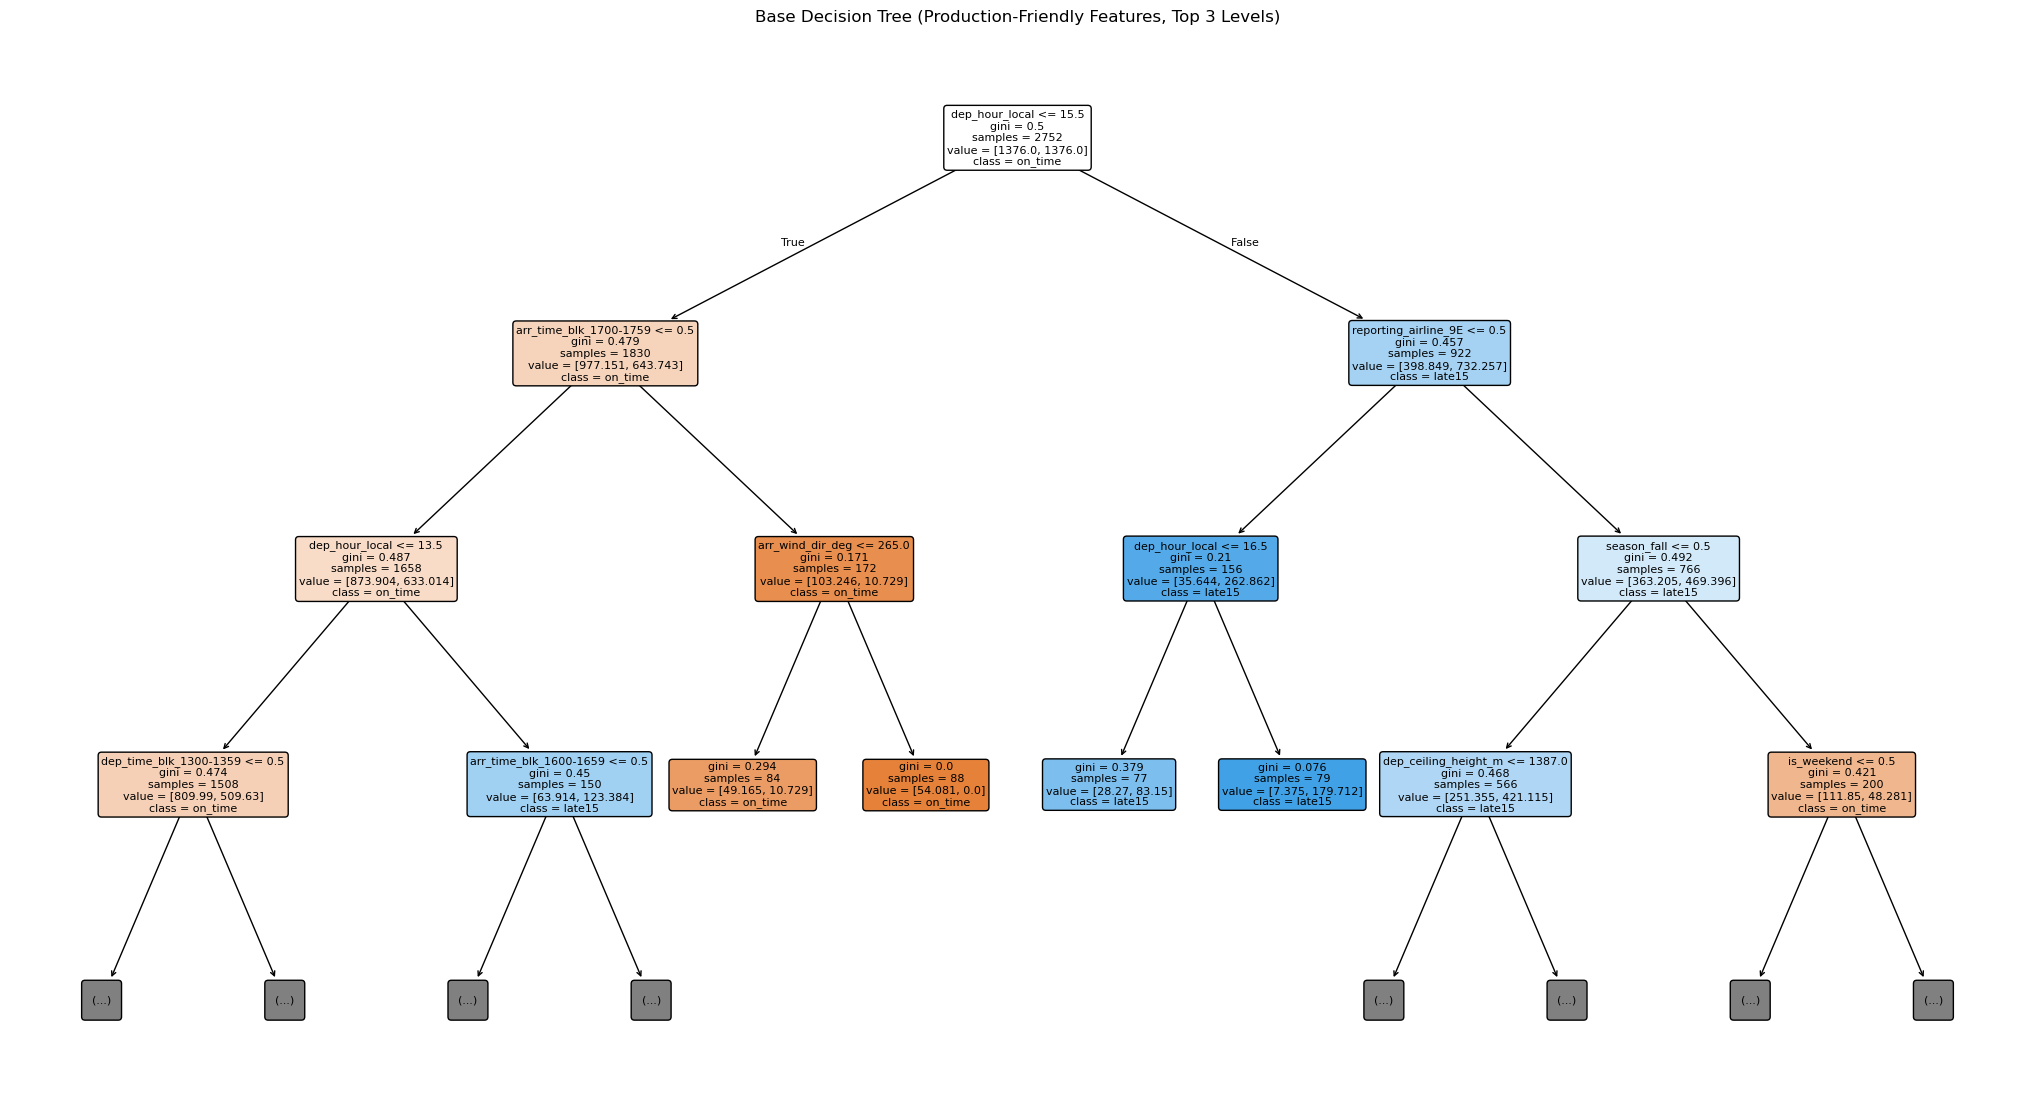

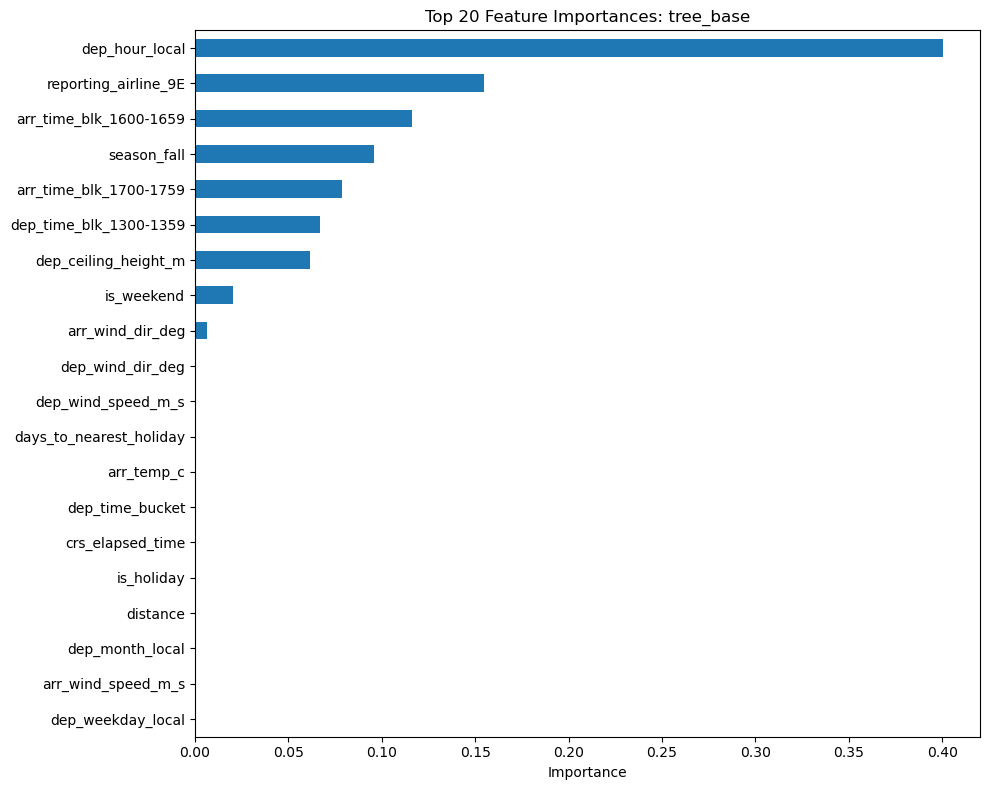


Top built-in feature importances for tree_base:
dep_hour_local             0.400251
reporting_airline_9E       0.154583
arr_time_blk_1600-1659     0.116190
season_fall                0.095578
arr_time_blk_1700-1759     0.078897
dep_time_blk_1300-1359     0.066708
dep_ceiling_height_m       0.061290
is_weekend                 0.020109
arr_wind_dir_deg           0.006392
dep_time_bucket            0.000000
is_holiday                 0.000000
crs_elapsed_time           0.000000
dep_weekday_local          0.000000
dep_month_local            0.000000
distance                   0.000000
arr_wind_speed_m_s         0.000000
arr_temp_c                 0.000000
dep_wind_dir_deg           0.000000
dep_wind_speed_m_s         0.000000
days_to_nearest_holiday    0.000000
dtype: float64


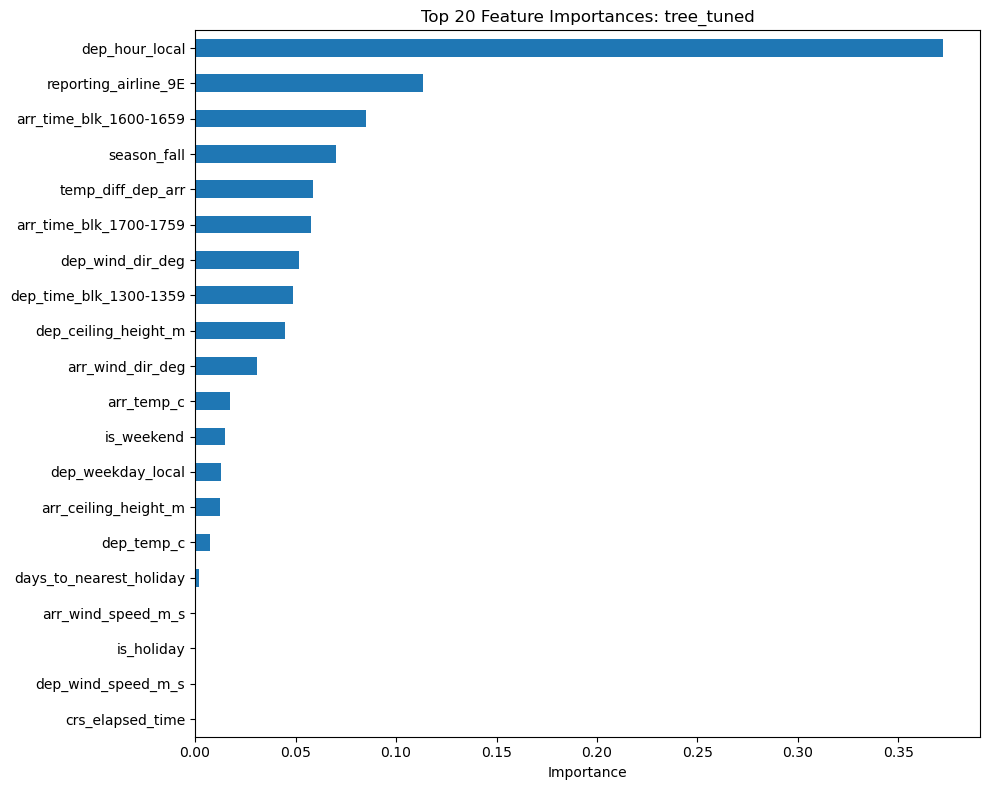


Top built-in feature importances for tree_tuned:
dep_hour_local             0.371990
reporting_airline_9E       0.113317
arr_time_blk_1600-1659     0.085174
season_fall                0.070064
temp_diff_dep_arr          0.058447
arr_time_blk_1700-1759     0.057836
dep_wind_dir_deg           0.051721
dep_time_blk_1300-1359     0.048901
dep_ceiling_height_m       0.044929
arr_wind_dir_deg           0.030804
arr_temp_c                 0.017184
is_weekend                 0.014741
dep_weekday_local          0.012911
arr_ceiling_height_m       0.012626
dep_temp_c                 0.007212
days_to_nearest_holiday    0.002143
arr_wind_speed_m_s         0.000000
is_holiday                 0.000000
dep_wind_speed_m_s         0.000000
crs_elapsed_time           0.000000
dtype: float64


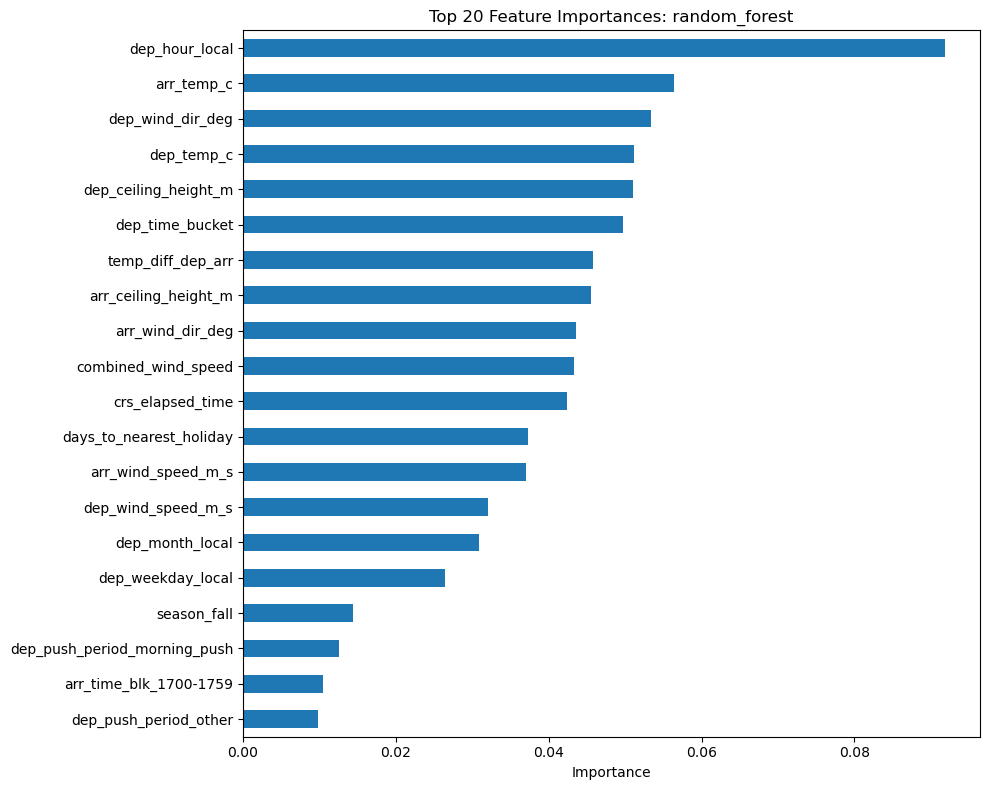


Top built-in feature importances for random_forest:
dep_hour_local                  0.091841
arr_temp_c                      0.056401
dep_wind_dir_deg                0.053435
dep_temp_c                      0.051173
dep_ceiling_height_m            0.051014
dep_time_bucket                 0.049720
temp_diff_dep_arr               0.045823
arr_ceiling_height_m            0.045467
arr_wind_dir_deg                0.043606
combined_wind_speed             0.043331
crs_elapsed_time                0.042357
days_to_nearest_holiday         0.037220
arr_wind_speed_m_s              0.037080
dep_wind_speed_m_s              0.032005
dep_month_local                 0.030808
dep_weekday_local               0.026381
season_fall                     0.014447
dep_push_period_morning_push    0.012556
arr_time_blk_1700-1759          0.010488
dep_push_period_other           0.009848
dtype: float64


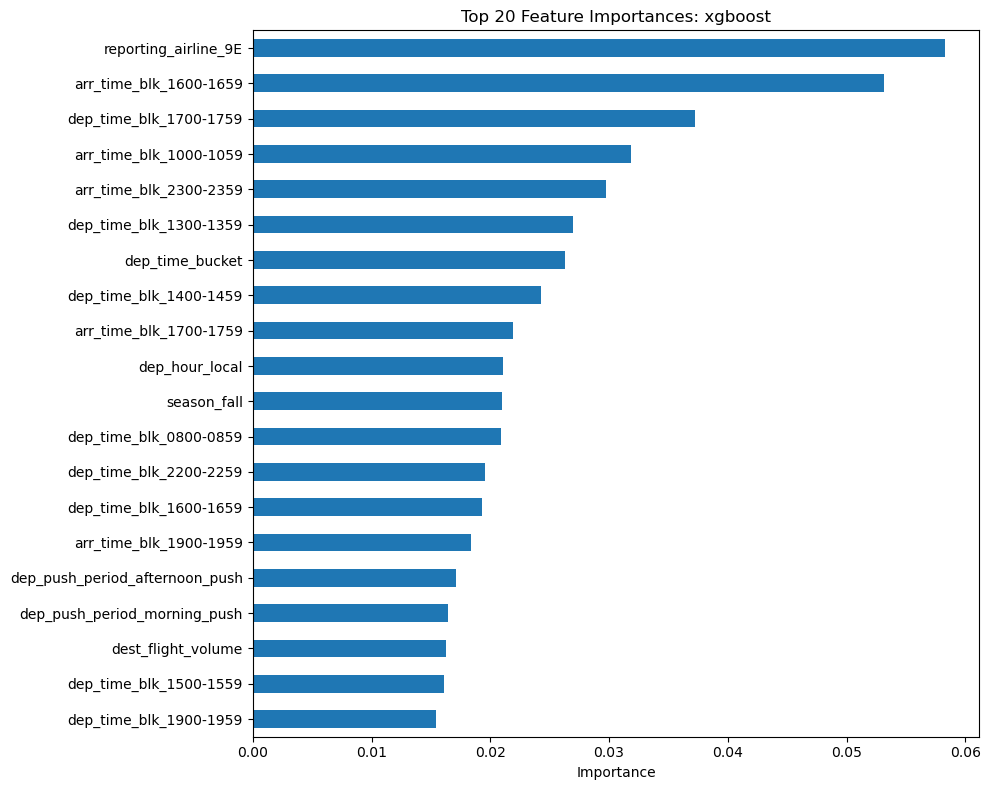


Top built-in feature importances for xgboost:
reporting_airline_9E              0.058249
arr_time_blk_1600-1659            0.053160
dep_time_blk_1700-1759            0.037268
arr_time_blk_1000-1059            0.031834
arr_time_blk_2300-2359            0.029720
dep_time_blk_1300-1359            0.026937
dep_time_bucket                   0.026287
dep_time_blk_1400-1459            0.024263
arr_time_blk_1700-1759            0.021888
dep_hour_local                    0.021109
season_fall                       0.020945
dep_time_blk_0800-0859            0.020912
dep_time_blk_2200-2259            0.019539
dep_time_blk_1600-1659            0.019275
arr_time_blk_1900-1959            0.018364
dep_push_period_afternoon_push    0.017106
dep_push_period_morning_push      0.016416
dest_flight_volume                0.016311
dep_time_blk_1500-1559            0.016073
dep_time_blk_1900-1959            0.015463
dtype: float32


<Figure size 1000x800 with 0 Axes>

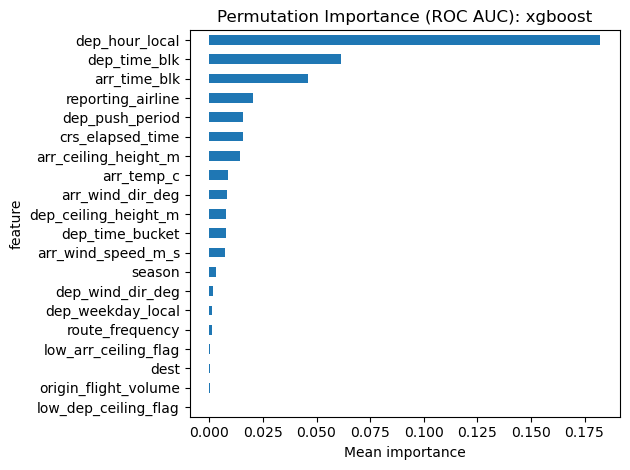


Top permutation importance features for xgboost:
                 feature  importance_mean  importance_std
8         dep_hour_local         0.182417        0.016536
6           dep_time_blk         0.061210        0.003241
7           arr_time_blk         0.045972        0.008933
0      reporting_airline         0.020471        0.005372
16       dep_push_period         0.015748        0.004159
5       crs_elapsed_time         0.015664        0.004178
24  arr_ceiling_height_m         0.014275        0.001699
21            arr_temp_c         0.008751        0.002485
23      arr_wind_dir_deg         0.008112        0.005508
20  dep_ceiling_height_m         0.007807        0.004164
11       dep_time_bucket         0.007619        0.002142
22    arr_wind_speed_m_s         0.007144        0.003245
15                season         0.003004        0.006256
19      dep_wind_dir_deg         0.001520        0.003672
9      dep_weekday_local         0.001185        0.002688
29       route_frequen

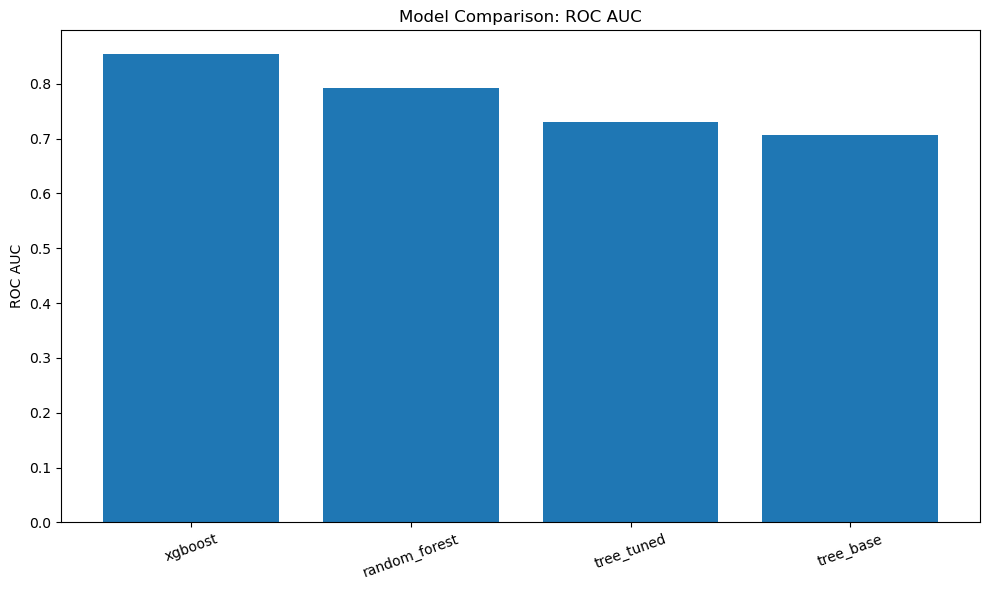

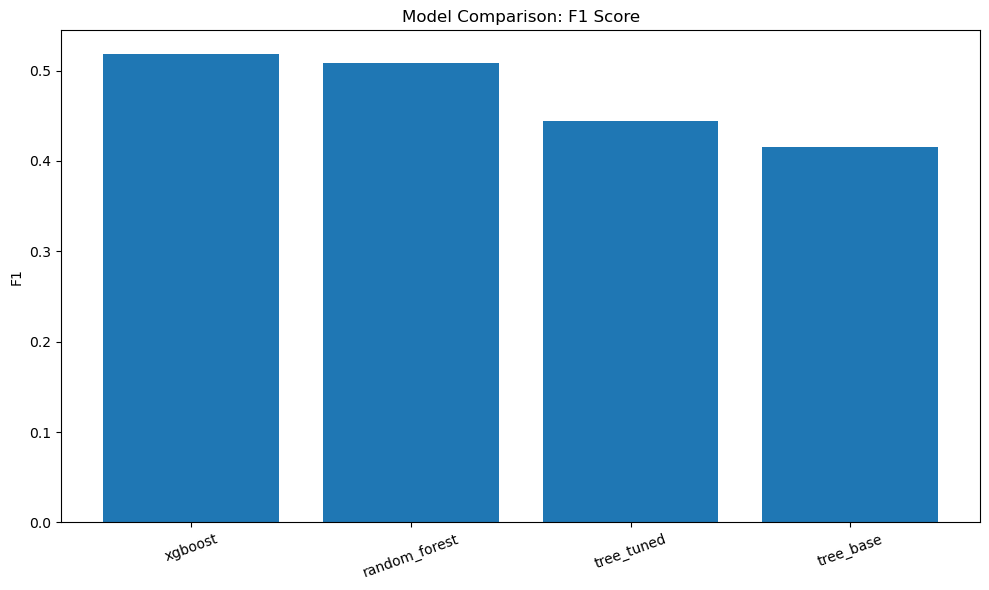

In [7]:
# ============================================================
# PRODUCTION-FRIENDLY TREE MODELS
# BWI <-> NEW YORK MARKET
# Uses only features that are realistic to obtain in production:
# - schedule
# - calendar
# - route / airline
# - weather
# ============================================================

from pathlib import Path
import sys
import importlib
import warnings

import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
)
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")

# Optional XGBoost
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False

# ------------------------------------------------------------
# Display config
# ------------------------------------------------------------
pl.Config.set_tbl_rows(1000)
pl.Config.set_tbl_cols(100)
pl.Config.set_tbl_width_chars(200)

# ------------------------------------------------------------
# Locate shared-notebooks and load utility
# ------------------------------------------------------------
current = Path.cwd()

while current.name != "shared-notebooks":
    if current.parent == current:
        raise RuntimeError("Could not locate shared-notebooks directory")
    current = current.parent

utils_path = current / "common_utils" / "python"
if str(utils_path) not in sys.path:
    sys.path.append(str(utils_path))

import load_flight_data
importlib.reload(load_flight_data)

# ------------------------------------------------------------
# Load canonical dataset
# ------------------------------------------------------------
lf = load_flight_data.load_flight_data(file_name="flights_canonical_2019.parquet")

# ------------------------------------------------------------
# Holiday list
# ------------------------------------------------------------
US_HOLIDAYS_2019 = [
    "2019-01-01",
    "2019-01-21",
    "2019-02-18",
    "2019-05-27",
    "2019-07-04",
    "2019-09-02",
    "2019-10-14",
    "2019-11-11",
    "2019-11-28",
    "2019-12-25",
]

NY_AIRPORTS = ["JFK", "LGA", "EWR"]

# ------------------------------------------------------------
# Keep only production-available raw fields
# ------------------------------------------------------------
RAW_FEATURES = [
    "flight_id",
    "reporting_airline",
    "origin",
    "dest",
    "route_key",
    "distance",
    "flight_date",

    # schedule / time
    "dep_hour_local",
    "dep_weekday_local",
    "dep_month_local",
    "crs_elapsed_time",
    "dep_time_blk",
    "arr_time_blk",
    "dep_ts_sched_utc",
    "arr_ts_sched_utc",

    # weather
    "dep_temp_c",
    "dep_wind_speed_m_s",
    "dep_wind_dir_deg",
    "dep_ceiling_height_m",
    "arr_temp_c",
    "arr_wind_speed_m_s",
    "arr_wind_dir_deg",
    "arr_ceiling_height_m",

    # target / status
    "arr_del15",
    "is_cancelled",
    "is_diverted",
]

# ------------------------------------------------------------
# Filter usable rows
# ------------------------------------------------------------
ml_lf = (
    lf
    .select(RAW_FEATURES)
    .filter(
        (pl.col("is_cancelled") == 0) &
        (pl.col("is_diverted") == 0) &
        pl.col("arr_del15").is_not_null()
    )
)

# ------------------------------------------------------------
# Feature engineering using production-safe information
# ------------------------------------------------------------
lf_features = (
    ml_lf
    .with_columns([
        # time-of-day bucket
        pl.when(pl.col("dep_hour_local") < 6).then(1)
        .when(pl.col("dep_hour_local") < 11).then(2)
        .when(pl.col("dep_hour_local") < 14).then(3)
        .when(pl.col("dep_hour_local") < 18).then(4)
        .when(pl.col("dep_hour_local") < 21).then(5)
        .otherwise(6)
        .alias("dep_time_bucket"),

        # weekend flag
        pl.col("dep_weekday_local").is_in([6, 7]).cast(pl.Int8).alias("is_weekend"),

        # holiday flag
        pl.col("flight_date")
        .cast(pl.Utf8)
        .is_in(US_HOLIDAYS_2019)
        .cast(pl.Int8)
        .alias("is_holiday"),

        # distance to nearest holiday
        pl.min_horizontal([
            *[
                (
                    pl.col("flight_date").cast(pl.Date)
                    - pl.lit(h).str.strptime(pl.Date)
                ).abs().dt.total_days()
                for h in US_HOLIDAYS_2019
            ]
        ]).alias("days_to_nearest_holiday"),

        # season buckets
        pl.when(pl.col("dep_month_local").is_in([12, 1, 2])).then(pl.lit("winter"))
        .when(pl.col("dep_month_local").is_in([3, 4, 5])).then(pl.lit("spring"))
        .when(pl.col("dep_month_local").is_in([6, 7, 8])).then(pl.lit("summer"))
        .otherwise(pl.lit("fall"))
        .alias("season"),

        # rough rush-hour proxy
        pl.when(pl.col("dep_hour_local").is_in([6, 7, 8, 9])).then(pl.lit("morning_push"))
        .when(pl.col("dep_hour_local").is_in([15, 16, 17, 18, 19])).then(pl.lit("afternoon_push"))
        .otherwise(pl.lit("other"))
        .alias("dep_push_period"),

        # weather interaction features
        (
            pl.coalesce([pl.col("dep_wind_speed_m_s"), pl.lit(0)]) +
            pl.coalesce([pl.col("arr_wind_speed_m_s"), pl.lit(0)])
        ).alias("combined_wind_speed"),

        (
            pl.coalesce([pl.col("dep_ceiling_height_m"), pl.lit(99999)]) <
            1000
        ).cast(pl.Int8).alias("low_dep_ceiling_flag"),

        (
            pl.coalesce([pl.col("arr_ceiling_height_m"), pl.lit(99999)]) <
            1000
        ).cast(pl.Int8).alias("low_arr_ceiling_flag"),

        (
            pl.coalesce([pl.col("dep_temp_c"), pl.lit(0)]) -
            pl.coalesce([pl.col("arr_temp_c"), pl.lit(0)])
        ).alias("temp_diff_dep_arr"),

        # network / market structure features that are still production-safe
        pl.len().over("route_key").alias("route_frequency"),
        pl.len().over("origin").alias("origin_flight_volume"),
        pl.len().over("dest").alias("dest_flight_volume"),
    ])
)

# ------------------------------------------------------------
# Focus market: BWI <-> New York
# ------------------------------------------------------------
market_lf = (
    lf_features
    .filter(
        (
            (pl.col("origin") == "BWI") & pl.col("dest").is_in(NY_AIRPORTS)
        ) |
        (
            (pl.col("dest") == "BWI") & pl.col("origin").is_in(NY_AIRPORTS)
        )
    )
)

# ------------------------------------------------------------
# Collect to pandas
# ------------------------------------------------------------
df = market_lf.collect().to_pandas()

print("Shape:", df.shape)
print(df[["origin", "dest", "arr_del15"]].head())

# ------------------------------------------------------------
# Target
# ------------------------------------------------------------
TARGET = "arr_del15"

# ------------------------------------------------------------
# Production-safe predictors only
# ------------------------------------------------------------
candidate_features = [
    # market / schedule
    "reporting_airline",
    "origin",
    "dest",
    "route_key",
    "distance",
    "crs_elapsed_time",
    "dep_time_blk",
    "arr_time_blk",
    "dep_hour_local",
    "dep_weekday_local",
    "dep_month_local",
    "dep_time_bucket",
    "is_weekend",
    "is_holiday",
    "days_to_nearest_holiday",
    "season",
    "dep_push_period",

    # weather
    "dep_temp_c",
    "dep_wind_speed_m_s",
    "dep_wind_dir_deg",
    "dep_ceiling_height_m",
    "arr_temp_c",
    "arr_wind_speed_m_s",
    "arr_wind_dir_deg",
    "arr_ceiling_height_m",
    "combined_wind_speed",
    "low_dep_ceiling_flag",
    "low_arr_ceiling_flag",
    "temp_diff_dep_arr",

    # production-safe traffic / structure
    "route_frequency",
    "origin_flight_volume",
    "dest_flight_volume",
]

candidate_features = [c for c in candidate_features if c in df.columns]

model_df = df[candidate_features + [TARGET]].copy()
model_df = model_df[model_df[TARGET].notna()].copy()
model_df[TARGET] = model_df[TARGET].astype(int)

print("\nModel frame shape:", model_df.shape)
print("\nTarget distribution:")
print(model_df[TARGET].value_counts(dropna=False))

# ------------------------------------------------------------
# Train/test split
# ------------------------------------------------------------
X = model_df[candidate_features]
y = model_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ------------------------------------------------------------
# Identify categorical vs numeric columns
# ------------------------------------------------------------
categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = [c for c in X_train.columns if c not in categorical_cols]

print("\nCategorical columns:", len(categorical_cols))
print("Numeric columns:", len(numeric_cols))

# ------------------------------------------------------------
# Preprocessing
# ------------------------------------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
            ]),
            numeric_cols,
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore")),
            ]),
            categorical_cols,
        ),
    ]
)

# ------------------------------------------------------------
# Models
# ------------------------------------------------------------
models = {
    "tree_base": DecisionTreeClassifier(
        max_depth=4,
        min_samples_leaf=50,
        class_weight="balanced",
        random_state=42,
    ),
    "tree_tuned": DecisionTreeClassifier(
        max_depth=6,
        min_samples_leaf=20,
        min_samples_split=80,
        class_weight="balanced",
        random_state=42,
    ),
    "random_forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=8,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=42,
    ),
}

if HAS_XGB:
    models["xgboost"] = XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
    )
else:
    models["gradient_boosting"] = GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42,
    )

# ------------------------------------------------------------
# Fit and evaluate
# ------------------------------------------------------------
fitted_models = {}
results = []

for model_name, estimator in models.items():
    pipe = Pipeline([
        ("prep", preprocessor),
        ("model", estimator),
    ])

    pipe.fit(X_train, y_train)
    fitted_models[model_name] = pipe

    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    results.append({
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_prob),
        "pr_auc": average_precision_score(y_test, y_prob),
    })

results_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False).reset_index(drop=True)

print("\n================ MODEL COMPARISON ================\n")
print(results_df)

# ------------------------------------------------------------
# Helper for transformed feature names
# ------------------------------------------------------------
def get_feature_names_from_preprocessor(preprocessor, numeric_cols, categorical_cols):
    feature_names = []
    feature_names.extend(numeric_cols)

    if len(categorical_cols) > 0:
        ohe = preprocessor.named_transformers_["cat"].named_steps["onehot"]
        cat_names = ohe.get_feature_names_out(categorical_cols).tolist()
        feature_names.extend(cat_names)

    return feature_names

# ------------------------------------------------------------
# Plot base tree
# ------------------------------------------------------------
tree_pipe = fitted_models["tree_base"]
tree_prep = tree_pipe.named_steps["prep"]
tree_model = tree_pipe.named_steps["model"]

tree_feature_names = get_feature_names_from_preprocessor(
    tree_prep,
    numeric_cols,
    categorical_cols
)

plt.figure(figsize=(26, 14))
plot_tree(
    tree_model,
    feature_names=tree_feature_names,
    class_names=["on_time", "late15"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8,
)
plt.title("Base Decision Tree (Production-Friendly Features, Top 3 Levels)")
plt.show()

# ------------------------------------------------------------
# Built-in feature importances
# ------------------------------------------------------------
def plot_builtin_feature_importance(model_name, fitted_pipe, top_n=20):
    model = fitted_pipe.named_steps["model"]
    prep = fitted_pipe.named_steps["prep"]

    feature_names = get_feature_names_from_preprocessor(prep, numeric_cols, categorical_cols)

    if not hasattr(model, "feature_importances_"):
        print(f"{model_name}: no built-in feature importance available.")
        return None

    imp = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=False)
    top_imp = imp.head(top_n).sort_values(ascending=True)

    plt.figure(figsize=(10, 8))
    top_imp.plot(kind="barh")
    plt.title(f"Top {top_n} Feature Importances: {model_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

    print(f"\nTop built-in feature importances for {model_name}:")
    print(imp.head(top_n))
    return imp

all_importances = {}
for model_name, fitted_pipe in fitted_models.items():
    imp = plot_builtin_feature_importance(model_name, fitted_pipe, top_n=20)
    all_importances[model_name] = imp

# ------------------------------------------------------------
# Permutation importance for best model
# ------------------------------------------------------------
best_model_name = results_df.iloc[0]["model"]
best_pipe = fitted_models[best_model_name]

perm = permutation_importance(
    best_pipe,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=5,
    random_state=42,
)

perm_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False)

plt.figure(figsize=(10, 8))
perm_df.head(20).sort_values("importance_mean").plot(
    x="feature",
    y="importance_mean",
    kind="barh",
    legend=False
)
plt.title(f"Permutation Importance (ROC AUC): {best_model_name}")
plt.xlabel("Mean importance")
plt.tight_layout()
plt.show()

print(f"\nTop permutation importance features for {best_model_name}:")
print(perm_df.head(20))

# ------------------------------------------------------------
# Best model report
# ------------------------------------------------------------
best_probs = best_pipe.predict_proba(X_test)[:, 1]
best_pred = (best_probs >= 0.5).astype(int)

print("\n================ BEST MODEL REPORT ================\n")
print("Best model:", best_model_name)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, best_pred))

print("\nClassification Report:")
print(classification_report(y_test, best_pred, digits=3))

# ------------------------------------------------------------
# Simple market summaries for interpretation
# ------------------------------------------------------------
analysis_df = X_test.copy()
analysis_df["actual_late15"] = y_test.values
analysis_df["pred_prob_late15"] = best_probs
analysis_df["pred_late15"] = best_pred

route_summary = (
    analysis_df
    .groupby(["origin", "dest"], dropna=False)
    .agg(
        flights=("actual_late15", "size"),
        actual_delay_rate=("actual_late15", "mean"),
        avg_predicted_risk=("pred_prob_late15", "mean"),
    )
    .reset_index()
    .sort_values("actual_delay_rate", ascending=False)
)

print("\n================ ROUTE SUMMARY ================\n")
print(route_summary)

time_summary = (
    analysis_df
    .groupby(["dep_time_bucket", "dep_push_period"], dropna=False)
    .agg(
        flights=("actual_late15", "size"),
        actual_delay_rate=("actual_late15", "mean"),
        avg_predicted_risk=("pred_prob_late15", "mean"),
    )
    .reset_index()
    .sort_values(["actual_delay_rate", "flights"], ascending=[False, False])
)

print("\n================ TIME-OF-DAY SUMMARY ================\n")
print(time_summary)

weather_summary = (
    analysis_df
    .groupby(["low_dep_ceiling_flag", "low_arr_ceiling_flag"], dropna=False)
    .agg(
        flights=("actual_late15", "size"),
        actual_delay_rate=("actual_late15", "mean"),
        avg_predicted_risk=("pred_prob_late15", "mean"),
    )
    .reset_index()
    .sort_values(["actual_delay_rate", "flights"], ascending=[False, False])
)

print("\n================ WEATHER SUMMARY ================\n")
print(weather_summary)

# ------------------------------------------------------------
# High-risk examples
# ------------------------------------------------------------
display_cols = [c for c in [
    "reporting_airline",
    "origin",
    "dest",
    "dep_hour_local",
    "dep_time_blk",
    "dep_push_period",
    "dep_temp_c",
    "dep_wind_speed_m_s",
    "dep_ceiling_height_m",
    "arr_temp_c",
    "arr_wind_speed_m_s",
    "arr_ceiling_height_m",
    "combined_wind_speed",
    "low_dep_ceiling_flag",
    "low_arr_ceiling_flag",
] if c in analysis_df.columns]

high_risk_examples = analysis_df.copy()
high_risk_examples["actual_late15"] = y_test.values
high_risk_examples["pred_prob_late15"] = best_probs

high_risk_examples = high_risk_examples.sort_values("pred_prob_late15", ascending=False)

print("\n================ TOP HIGH-RISK EXAMPLES ================\n")
print(
    high_risk_examples[
        display_cols + ["actual_late15", "pred_prob_late15"]
    ].head(20)
)

# ------------------------------------------------------------
# Model comparison plots
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))
plt.bar(results_df["model"], results_df["roc_auc"])
plt.title("Model Comparison: ROC AUC")
plt.ylabel("ROC AUC")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.bar(results_df["model"], results_df["f1"])
plt.title("Model Comparison: F1 Score")
plt.ylabel("F1")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()